# Phase 1: Acquire

Install Apache PySpark in the Colab runtime.

In [ ]:
!pip install pyspark -q

## Download the dataset

Fetch the Individual Household Electric Power Consumption dataset from the UCI Machine Learning Repository and decompress it locally.

In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip -O hpc.zip
!unzip -o hpc.zip

Archive:  hpc.zip
  inflating: household_power_consumption.txt  


## Initialise the Spark session

Configure a Spark session with 4 GB driver memory, suitable for processing the 2 million+ records on Colab's standard runtime.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HouseholdPower") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

## Load the raw dataset

Read the semicolon-delimited file using the Spark CSV reader. The `?` token is treated as null on the way in. All numeric fields arrive as strings due to the embedded `?` sentinels — type casting follows in the next phase.

In [ ]:
df = spark.read.csv(
    "household_power_consumption.txt",
    sep=";",
    header=True,
    nullValue="?"
)

print("Total rows:", df.count())
df.printSchema()
df.show(5)

Total rows: 2075259
root
 |-- Date: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- Global_active_power: string (nullable = true)
 |-- Global_reactive_power: string (nullable = true)
 |-- Voltage: string (nullable = true)
 |-- Global_intensity: string (nullable = true)
 |-- Sub_metering_1: string (nullable = true)
 |-- Sub_metering_2: string (nullable = true)
 |-- Sub_metering_3: string (nullable = true)

+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+
|      Date|    Time|Global_active_power|Global_reactive_power|Voltage|Global_intensity|Sub_metering_1|Sub_metering_2|Sub_metering_3|
+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+
|16/12/2006|17:24:00|              4.216|                0.418|234.840|          18.400|         0.000|         1.000|        17.000|
|16/12/2006|17:25:00|              5.

# Phase 2: Prepare

## Cast numeric columns

Convert the seven numeric columns from string to double precision so they can be used in aggregations and modelling.

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

numeric_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
                "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

for c in numeric_cols:
    df = df.withColumn(c, col(c).cast(DoubleType()))

df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- Global_active_power: double (nullable = true)
 |-- Global_reactive_power: double (nullable = true)
 |-- Voltage: double (nullable = true)
 |-- Global_intensity: double (nullable = true)
 |-- Sub_metering_1: double (nullable = true)
 |-- Sub_metering_2: double (nullable = true)
 |-- Sub_metering_3: double (nullable = true)



## Detect missing values

Count nulls in every column. Each numeric column has 25,979 nulls (~1.25% of records), while Date and Time are fully populated.

In [ ]:
from pyspark.sql.functions import sum as _sum

df.select([_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+----+----+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+
|Date|Time|Global_active_power|Global_reactive_power|Voltage|Global_intensity|Sub_metering_1|Sub_metering_2|Sub_metering_3|
+----+----+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+
|   0|   0|              25979|                25979|  25979|           25979|         25979|         25979|         25979|
+----+----+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+



## Drop rows with nulls

Since the missing readings affect entire rows simultaneously (the meter was offline at that minute), imputation would synthesise physically impossible records. Dropping leaves 2,049,280 complete rows — a 98.75% retention rate.

In [ ]:
df_clean = df.dropna()
print("Rows after dropna:", df_clean.count())

Rows after dropna: 2049280


## Engineer temporal features

Combine Date and Time into a Spark timestamp, then extract `year`, `month`, `dayofweek`, and `hour` as separate columns for grouping and modelling.

In [ ]:
from pyspark.sql.functions import to_timestamp, concat_ws, year, month, dayofweek, hour

df_clean = df_clean.withColumn(
    "datetime",
    to_timestamp(concat_ws(" ", col("Date"), col("Time")), "d/M/yyyy HH:mm:ss")
)

df_clean = df_clean.withColumn("year", year("datetime")) \
                   .withColumn("month", month("datetime")) \
                   .withColumn("dayofweek", dayofweek("datetime")) \
                   .withColumn("hour", hour("datetime"))

df_clean.show(3)

+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+-------------------+----+-----+---------+----+
|      Date|    Time|Global_active_power|Global_reactive_power|Voltage|Global_intensity|Sub_metering_1|Sub_metering_2|Sub_metering_3|           datetime|year|month|dayofweek|hour|
+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+-------------------+----+-----+---------+----+
|16/12/2006|17:24:00|              4.216|                0.418| 234.84|            18.4|           0.0|           1.0|          17.0|2006-12-16 17:24:00|2006|   12|        7|  17|
|16/12/2006|17:25:00|               5.36|                0.436| 233.63|            23.0|           0.0|           1.0|          16.0|2006-12-16 17:25:00|2006|   12|        7|  17|
|16/12/2006|17:26:00|              5.374|                0.498| 233.29|            23.0|           0

## Subset to January 2007

Filter to a single month yielding 44,638 records — a manageable subset for visualisation and ML training that still captures the full hour-of-day and day-of-week structure.

In [ ]:
df_subset = df_clean.filter((col("year") == 2007) & (col("month") == 1))
print("Subset rows:", df_subset.count())

Subset rows: 44638


## Descriptive statistics

Compute count, mean, standard deviation, min, and max for every numeric column on the cleaned subset.

In [ ]:
df_subset.describe(numeric_cols).show()

+-------+-------------------+---------------------+------------------+-----------------+------------------+------------------+-----------------+
|summary|Global_active_power|Global_reactive_power|           Voltage| Global_intensity|    Sub_metering_1|    Sub_metering_2|   Sub_metering_3|
+-------+-------------------+---------------------+------------------+-----------------+------------------+------------------+-----------------+
|  count|              44638|                44638|             44638|            44638|             44638|             44638|            44638|
|   mean|  1.546033917290203|  0.13267610556028359|240.90510125901744|6.546915184371784|1.2642367489582866|1.7759308212733544|7.383350508535329|
| stddev| 1.2920066304956912|  0.11832579467460712|3.4618342326078966|5.459576996879199| 6.584609919118104|  7.39587359055054|8.648723292543748|
|    min|              0.198|                  0.0|            224.68|              0.8|               0.0|               0.0|    

## Initial hourly aggregation

Average active power per hour of day. Two clear peaks emerge — 7–8 AM (breakfast) and 7–9 PM (dinner) — with a 3 AM overnight trough.

In [ ]:
from pyspark.sql.functions import mean

df_subset.groupBy("hour") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .orderBy("hour").show(24)

+----+------------------+
|hour|         avg_power|
+----+------------------+
|   0|1.1621752688172005|
|   1|0.8932311827956995|
|   2|0.8077849462365619|
|   3|0.7383301075268842|
|   4|0.7479892473118271|
|   5|  0.76118494623656|
|   6|0.9610075268817236|
|   7|1.9060666666666637|
|   8|1.9002215053763396|
|   9|1.6766569892473087|
|  10|1.5405720430107537|
|  11|1.5010989247311812|
|  12|1.5154193548387045|
|  13|1.3987322580645147|
|  14|1.3768537634408597|
|  15|1.5097602150537617|
|  16|1.6013774193548407|
|  17| 2.009249058633675|
|  18| 2.499814954276489|
|  19|2.6854236559139752|
|  20|2.7428451612903237|
|  21| 2.360906451612901|
|  22|  1.53789247311828|
|  23|1.2709817204301073|
+----+------------------+



## Save cleaned subset

Persist the cleaned January 2007 subset to CSV for downstream reuse.

In [ ]:
df_subset.coalesce(1).write.mode("overwrite").csv("cleaned_output", header=True)

## Duplicate check

Verify uniqueness of all rows. Zero duplicates are detected, confirming integrity of the cleaned dataset.

In [ ]:
total = df_subset.count()
unique = df_subset.dropDuplicates().count()
print("Total:", total, " Unique:", unique, " Duplicates:", total - unique)

Total: 44638  Unique: 44638  Duplicates: 0


## Physical sanity filter

Require voltage in the [200, 260] V range and non-negative active power. Zero rows are excluded, confirming all readings are physically valid.

In [ ]:
before = df_subset.count()

df_subset = df_subset.filter(
    (col("Voltage") > 200) & (col("Voltage") < 260) &
    (col("Global_active_power") >= 0)
)

print("Before:", before, " After:", df_subset.count())

Before: 44638  After: 44638


## Derive energy-balance features

Compute `sub_metering_total` (sum of the three sub-meters) and `unmetered` (the residual after converting Global Active Power to Wh per minute). Unmetered captures lighting, sockets, and other circuits not directly instrumented.

In [ ]:
df_subset = df_subset.withColumn(
    "sub_metering_total",
    col("Sub_metering_1") + col("Sub_metering_2") + col("Sub_metering_3")
)

df_subset = df_subset.withColumn(
    "unmetered",
    (col("Global_active_power") * 1000 / 60) - col("sub_metering_total")
)

df_subset.select("Global_active_power", "sub_metering_total", "unmetered").show(5)

+-------------------+------------------+-----------------+
|Global_active_power|sub_metering_total|        unmetered|
+-------------------+------------------+-----------------+
|               2.58|               0.0|             43.0|
|              2.552|               0.0|42.53333333333333|
|               2.55|               0.0|             42.5|
|               2.55|               0.0|             42.5|
|              2.554|               0.0|42.56666666666667|
+-------------------+------------------+-----------------+
only showing top 5 rows


## Import helpers for analysis

Bring in min/max aggregate functions for the EDA stage that follows.

In [ ]:
from pyspark.sql.functions import min as _min, max as _max

# Phase 3: Analyze

## Average power by day of week

Sunday is highest (2.08 kW) and Tuesday lowest (1.15 kW), suggesting a working-week pattern with elevated weekend occupancy.

In [ ]:
df_subset.groupBy("dayofweek") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .orderBy("dayofweek").show()

+---------+------------------+
|dayofweek|         avg_power|
+---------+------------------+
|        1|2.0758773879819525|
|        2|1.5697500000000078|
|        3|1.1541849999999971|
|        4|1.5789094444444478|
|        5|1.5507659722222302|
|        6|1.2626861111111036|
|        7|1.7140618055555579|
+---------+------------------+



## Power magnitude bucketisation

Bin active power readings into ranges. The 0–0.5 kW bucket dominates (overnight standby + low-load periods), confirming the right-skewed distribution.

In [ ]:
from pyspark.ml.feature import Bucketizer
from pyspark.sql.functions import count

splits = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
bucketizer = Bucketizer(splits=splits, inputCol="Global_active_power", outputCol="power_bucket")

bucketed = bucketizer.transform(df_subset)

bucketed.groupBy("power_bucket") \
    .agg(count("*").alias("count")) \
    .orderBy("power_bucket").show()

+------------+-----+
|power_bucket|count|
+------------+-----+
|         0.0|14671|
|         1.0| 3464|
|         2.0| 7402|
|         3.0| 5604|
|         4.0| 7936|
|         5.0| 4580|
|         6.0|  981|
+------------+-----+



## Power magnitude bucketisation

Bin active power readings into ranges. The 0–0.5 kW bucket dominates (overnight standby + low-load periods), confirming the right-skewed distribution.

In [ ]:
df_subset.agg(
    mean("Sub_metering_1").alias("kitchen_avg"),
    mean("Sub_metering_2").alias("laundry_avg"),
    mean("Sub_metering_3").alias("water_heater_ac_avg")
).show()

+------------------+------------------+-------------------+
|       kitchen_avg|       laundry_avg|water_heater_ac_avg|
+------------------+------------------+-------------------+
|1.2642367489582866|1.7759308212733544|  7.383350508535329|
+------------------+------------------+-------------------+



## Sub-metering circuit averages

Quantify the average consumption of each instrumented circuit. The water-heater + AC circuit dominates (7.38 Wh/min) versus laundry (1.78) and kitchen (1.26).

In [ ]:
df_subset.groupBy("dayofweek", "hour") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .orderBy("dayofweek", "hour").show(50)

+---------+----+-------------------+
|dayofweek|hour|          avg_power|
+---------+----+-------------------+
|        1|   0| 2.1970166666666655|
|        1|   1| 1.5377583333333327|
|        1|   2| 1.5462916666666673|
|        1|   3| 1.0152250000000003|
|        1|   4| 1.0283416666666672|
|        1|   5| 1.0238249999999995|
|        1|   6| 1.2888249999999999|
|        1|   7| 0.9774500000000006|
|        1|   8| 1.4457999999999998|
|        1|   9| 1.6744833333333338|
|        1|  10| 1.6699083333333327|
|        1|  11| 1.7734083333333326|
|        1|  12| 2.0391500000000002|
|        1|  13| 2.6907416666666655|
|        1|  14| 2.0154416666666672|
|        1|  15|  2.479125000000001|
|        1|  16| 2.2403166666666667|
|        1|  17| 2.9991799163179915|
|        1|  18| 3.9394728033472814|
|        1|  19|  3.508850000000002|
|        1|  20|  4.145966666666667|
|        1|  21|  3.958866666666665|
|        1|  22| 1.7064833333333336|
|        1|  23| 0.9307416666666672|
|

## Combined hour × day-of-week aggregation

Average power for each (day, hour) combination. Used to construct the heatmap visualisation later.

In [ ]:
from pyspark.sql.functions import dayofmonth, sum as _sum

df_subset.groupBy(dayofmonth("datetime").alias("day")) \
    .agg((_sum("Global_active_power") / 60).alias("total_kwh")) \
    .orderBy("day").show(31)

+---+------------------+
|day|         total_kwh|
+---+------------------+
|  1|45.816733333333595|
|  2| 21.15393333333334|
|  3| 16.90090000000001|
|  4| 54.32353333333318|
|  5| 45.22273333333321|
|  6| 25.13963333333333|
|  7|  40.7936666666667|
|  8| 37.35599999999996|
|  9|31.150899999999982|
| 10| 35.91333333333327|
| 11| 37.58656666666668|
| 12| 24.35493333333337|
| 13|53.113566666666635|
| 14|50.130266666666635|
| 15| 35.81129999999997|
| 16| 28.10673333333333|
| 17|47.461466666666645|
| 18| 30.35770000000002|
| 19|24.674000000000046|
| 20|52.228866666666605|
| 21|56.787699999999965|
| 22| 36.34156666666667|
| 23| 29.62733333333334|
| 24| 49.79756666666663|
| 25|26.605733333333294|
| 26|26.966199999999972|
| 27| 34.06786666666668|
| 28|51.503399999999814|
| 29|           33.0444|
| 30|28.463299999999972|
| 31| 39.39586666666669|
+---+------------------+



## Peak vs off-peak comparison

Segment hours into morning peak (7–9 AM), evening peak (6–9 PM), and off-peak. Evening peak averages 2× off-peak loading.

In [ ]:
from pyspark.sql.functions import when

df_peak = df_subset.withColumn(
    "period",
    when((col("hour") >= 7) & (col("hour") <= 9), "morning_peak")
    .when((col("hour") >= 18) & (col("hour") <= 21), "evening_peak")
    .otherwise("off_peak")
)

df_peak.groupBy("period") \
    .agg(mean("Global_active_power").alias("avg_power"),
         count("*").alias("minutes")) \
    .show()

+------------+------------------+-------+
|      period|         avg_power|minutes|
+------------+------------------+-------+
|    off_peak|1.2548961700243577|  31619|
|morning_peak|1.8276483870967755|   5580|
|evening_peak|2.5722572926468628|   7439|
+------------+------------------+-------+



## Weekday vs weekend comparison

Aggregate by weekend flag. The household consumes 33% more power on weekends than weekdays (1.89 kW vs 1.42 kW).

In [ ]:
df_we = df_subset.withColumn(
    "is_weekend",
    when((col("dayofweek") == 1) | (col("dayofweek") == 7), "weekend").otherwise("weekday")
)

df_we.groupBy("is_weekend") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .show()

+----------+------------------+
|is_weekend|         avg_power|
+----------+------------------+
|   weekday|1.4246969806763372|
|   weekend| 1.894938183712456|
+----------+------------------+



## Voltage stability analysis

Voltage holds steady at 240.91 V ± 3.46 V, well within the ±10% tolerance of the nominal 230 V French residential supply.

In [ ]:
from pyspark.sql.functions import min as _min, max as _max, stddev, count
df_subset.agg(
    mean("Voltage").alias("mean_v"),
    stddev("Voltage").alias("std_v"),
    _min("Voltage").alias("min_v"),
    _max("Voltage").alias("max_v")
).show()

+------------------+------------------+------+------+
|            mean_v|             std_v| min_v| max_v|
+------------------+------------------+------+------+
|240.90510125901744|3.4618342326078966|224.68|250.89|
+------------------+------------------+------+------+



# Phase 4: Report (Visualisation)

Import matplotlib for plotting on aggregated Spark output.

In [ ]:
import matplotlib.pyplot as plt

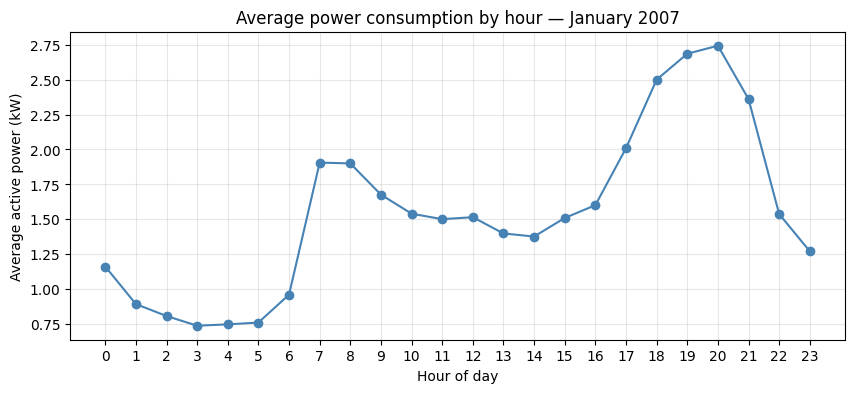

In [ ]:
hourly = df_subset.groupBy("hour") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .orderBy("hour").toPandas()

plt.figure(figsize=(10, 4))
plt.plot(hourly["hour"], hourly["avg_power"], marker="o", color="steelblue")
plt.xlabel("Hour of day")
plt.ylabel("Average active power (kW)")
plt.title("Average power consumption by hour — January 2007")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

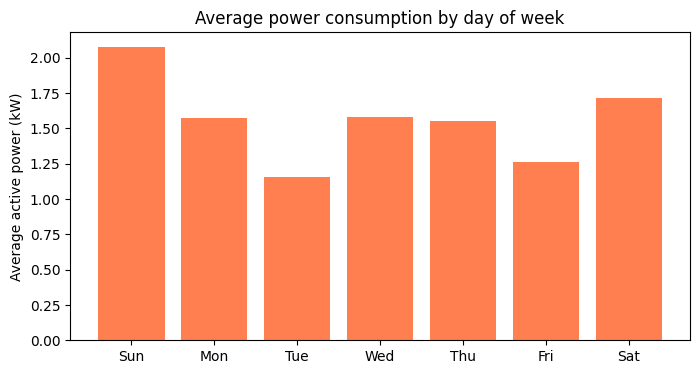

In [ ]:
dow = df_subset.groupBy("dayofweek") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .orderBy("dayofweek").toPandas()

days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

plt.figure(figsize=(8, 4))
plt.bar(days, dow["avg_power"], color="coral")
plt.ylabel("Average active power (kW)")
plt.title("Average power consumption by day of week")
plt.show()

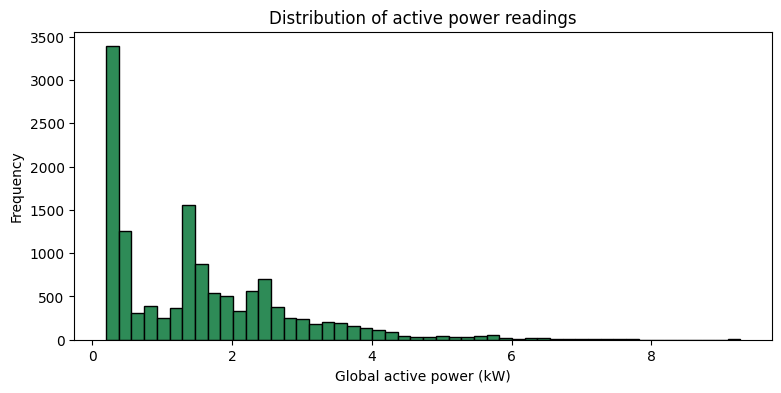

In [ ]:
sample = df_subset.select("Global_active_power").sample(0.3, seed=42).toPandas()

plt.figure(figsize=(9, 4))
plt.hist(sample["Global_active_power"], bins=50, color="seagreen", edgecolor="black")
plt.xlabel("Global active power (kW)")
plt.ylabel("Frequency")
plt.title("Distribution of active power readings")
plt.show()

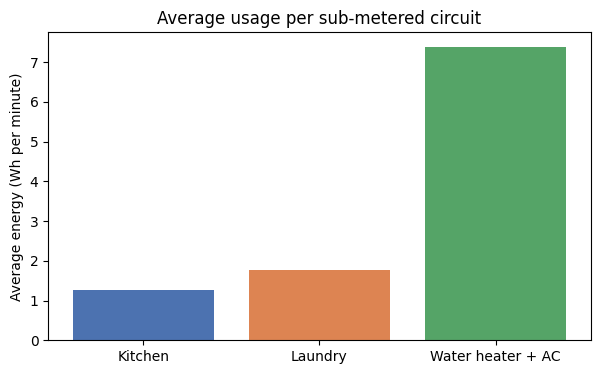

In [ ]:
sub = df_subset.agg(
    mean("Sub_metering_1").alias("Kitchen"),
    mean("Sub_metering_2").alias("Laundry"),
    mean("Sub_metering_3").alias("Water heater + AC")
).toPandas().T.reset_index()
sub.columns = ["circuit", "avg_wh"]

plt.figure(figsize=(7, 4))
plt.bar(sub["circuit"], sub["avg_wh"], color=["#4C72B0", "#DD8452", "#55A467"])
plt.ylabel("Average energy (Wh per minute)")
plt.title("Average usage per sub-metered circuit")
plt.show()

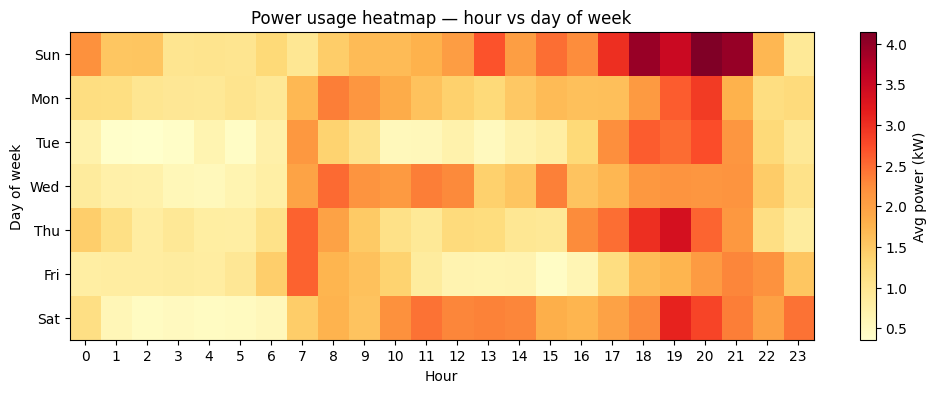

In [ ]:
heat = df_subset.groupBy("dayofweek", "hour") \
    .agg(mean("Global_active_power").alias("avg_power")) \
    .orderBy("dayofweek", "hour").toPandas()

pivot = heat.pivot(index="dayofweek", columns="hour", values="avg_power")

plt.figure(figsize=(12, 4))
plt.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Avg power (kW)")
plt.yticks(range(7), days)
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Day of week")
plt.title("Power usage heatmap — hour vs day of week")
plt.show()

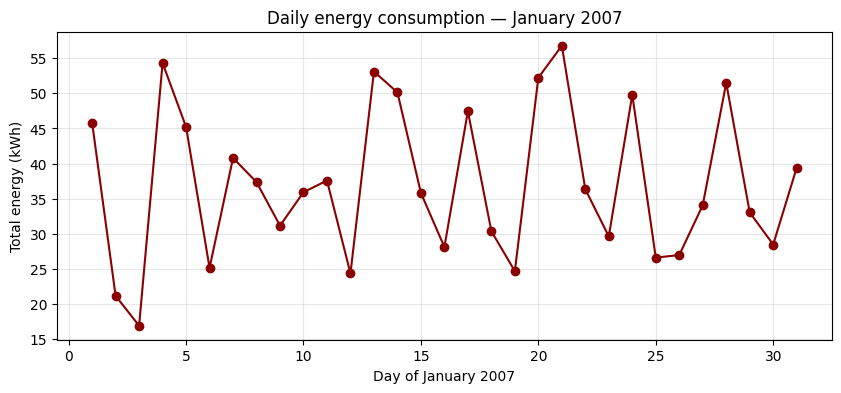

In [ ]:
from pyspark.sql.functions import dayofmonth, sum as _sum

daily = df_subset.groupBy(dayofmonth("datetime").alias("day")) \
    .agg((_sum("Global_active_power") / 60).alias("kwh")) \
    .orderBy("day").toPandas()

plt.figure(figsize=(10, 4))
plt.plot(daily["day"], daily["kwh"], marker="o", color="darkred")
plt.xlabel("Day of January 2007")
plt.ylabel("Total energy (kWh)")
plt.title("Daily energy consumption — January 2007")
plt.grid(alpha=0.3)
plt.show()

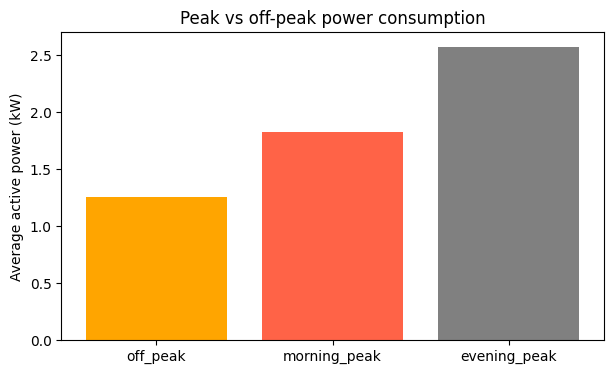

In [ ]:
peak = df_subset.withColumn(
    "period",
    when((col("hour") >= 7) & (col("hour") <= 9), "morning_peak")
    .when((col("hour") >= 18) & (col("hour") <= 21), "evening_peak")
    .otherwise("off_peak")
).groupBy("period").agg(mean("Global_active_power").alias("avg_power")).toPandas()

plt.figure(figsize=(7, 4))
plt.bar(peak["period"], peak["avg_power"], color=["orange", "tomato", "gray"])
plt.ylabel("Average active power (kW)")
plt.title("Peak vs off-peak power consumption")
plt.show()

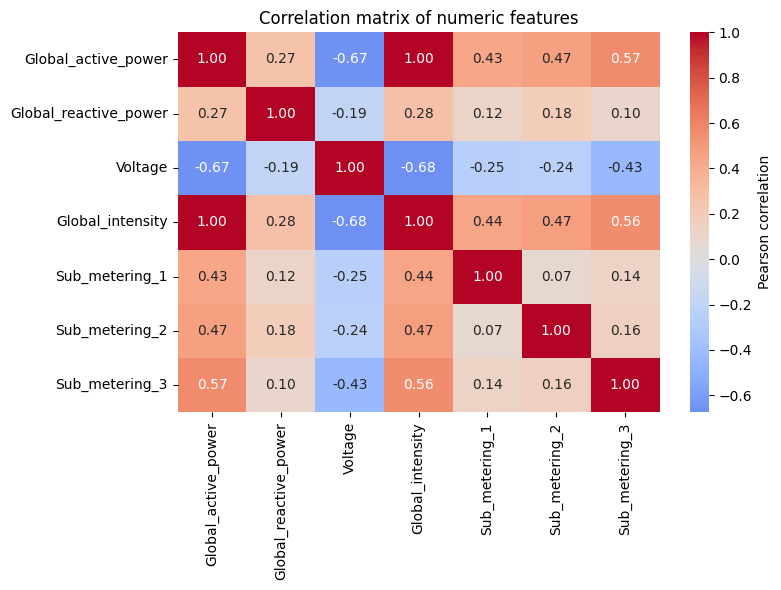

In [ ]:
!pip install seaborn -q
import seaborn as sns

corr_pdf = df_subset.select(numeric_cols).toPandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pdf, annot=True, cmap="coolwarm", fmt=".2f", center=0,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()

# Phase 5: Predict (Machine Learning)

Import scikit-learn modules for the regression pipeline. Spark handled distributed preprocessing; sklearn handles the final modelling stage on the cleaned subset.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Prepare the feature matrix

Select seven features and convert the cleaned Spark subset to a pandas DataFrame. Global Intensity is deliberately excluded because P = V × I creates near-perfect multicollinearity with the target — keeping it would constitute data leakage.

In [ ]:
feature_cols = ["Global_reactive_power", "Voltage",
                "Sub_metering_1", "Sub_metering_2", "Sub_metering_3",
                "hour", "dayofweek"]

target_col = "Global_active_power"

pdf = df_subset.select(feature_cols + [target_col]).toPandas()
print("Shape:", pdf.shape)
pdf.head()

Shape: (44638, 8)


,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,Global_active_power
0,0.136,241.97,0.0,0.0,0.0,0,2,2.580
1,0.100,241.75,0.0,0.0,0.0,0,2,2.552
2,0.100,241.64,0.0,0.0,0.0,0,2,2.550
3,0.100,241.71,0.0,0.0,0.0,0,2,2.550
4,0.100,241.98,0.0,0.0,0.0,0,2,2.554


## Train/test split

80/20 split with fixed seed for reproducibility. 35,710 training records, 8,928 test records.

In [ ]:
X = pdf[feature_cols]
y = pdf[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (35710, 7)  Test: (8928, 7)


## Feature scaling

Zero-mean, unit-variance standardisation fitted on training data and applied to both splits.


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Train Linear Regression

Ordinary least squares baseline. Provides a reference point against which non-linear models can be compared.

In [ ]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
print("Linear Regression trained")

Linear Regression trained


## Train Random Forest

100 trees, maximum depth 12, parallel training. An ensemble of decision trees capable of capturing non-linear feature interactions.

In [ ]:
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)
print("Random Forest trained")

Random Forest trained


## Random Forest feature importance

Quantify how much each feature contributed to the model's predictions. Sub_metering_3 emerges as the dominant signal (~39%).

In [ ]:
importances = rf.feature_importances_
ranked = sorted(zip(feature_cols, importances), key=lambda x: -x[1])

print("Feature importance (Random Forest):")
for feat, imp in ranked:
    print(f"   {feat:25} {imp:.4f}")

Feature importance (Random Forest):
   Sub_metering_3            0.3864
   Voltage                   0.2501
   Sub_metering_2            0.1135
   Sub_metering_1            0.0900
   hour                      0.0793
   dayofweek                 0.0458
   Global_reactive_power     0.0349


## Predicted vs Actual scatter

Diagnostic plot. Points clustering along the diagonal indicate accurate prediction; systematic departures indicate model weaknesses.

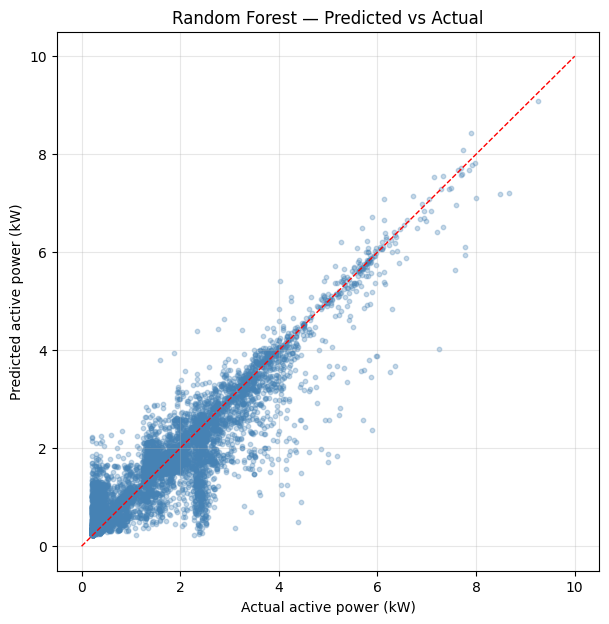

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_pred, alpha=0.3, s=10, color="steelblue")
plt.plot([0, 10], [0, 10], "r--", linewidth=1)
plt.xlabel("Actual active power (kW)")
plt.ylabel("Predicted active power (kW)")
plt.title("Random Forest — Predicted vs Actual")
plt.grid(alpha=0.3)
plt.show()

## Feature importance bar plot

Visual ranking of the seven features by contribution to the Random Forest predictions.

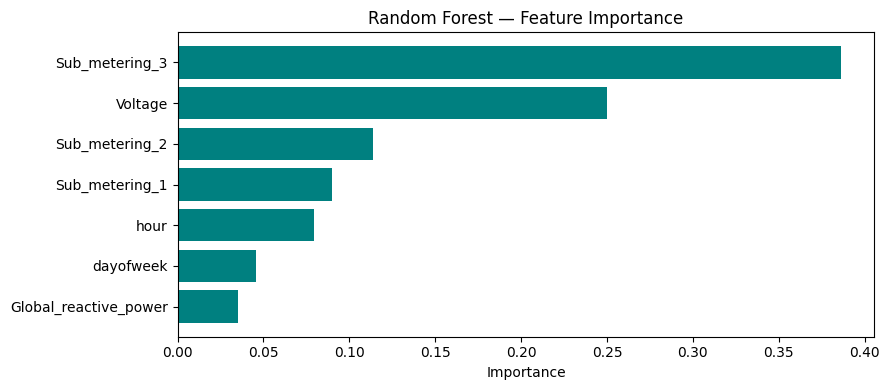

In [ ]:
feats = [f for f, _ in ranked]
imps = [i for _, i in ranked]

plt.figure(figsize=(9, 4))
plt.barh(feats[::-1], imps[::-1], color="teal")
plt.xlabel("Importance")
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

## Train Gradient Boosting

200 sequential estimators with shallow trees (depth 5). Each tree corrects errors of its predecessors, a different optimisation strategy than Random Forest's bagging.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_s, y_train)
gb_pred = gb.predict(X_test_s)
print("Gradient Boosting trained")

Gradient Boosting trained


In [ ]:
def score(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"   RMSE = {rmse:.4f}")
    print(f"   MAE  = {mae:.4f}")
    print(f"   R^2  = {r2:.4f}")
    print()

score(y_test, lr_pred, "Linear Regression")
score(y_test, rf_pred, "Random Forest")
score(y_test, gb_pred, "Gradient Boosting")

Linear Regression
   RMSE = 0.7051
   MAE  = 0.5269
   R^2  = 0.7008

Random Forest
   RMSE = 0.5104
   MAE  = 0.3250
   R^2  = 0.8432

Gradient Boosting
   RMSE = 0.5434
   MAE  = 0.3691
   R^2  = 0.8223



## Model comparison plot

Side-by-side bar charts of RMSE (lower = better) and R² (higher = better) across the three models.

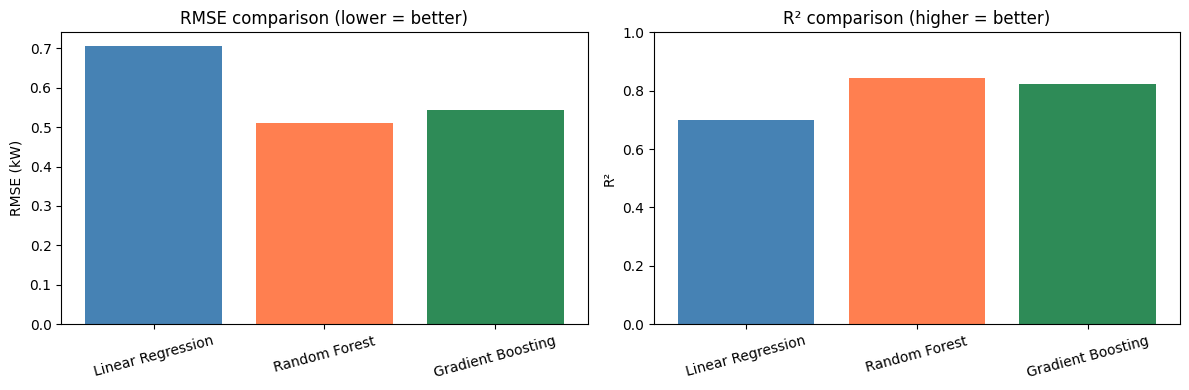

In [ ]:
models = ["Linear Regression", "Random Forest","Gradient Boosting"]
rmses = [
    np.sqrt(mean_squared_error(y_test, lr_pred)),
    np.sqrt(mean_squared_error(y_test, rf_pred)),
    np.sqrt(mean_squared_error(y_test, gb_pred))
]
r2s = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, gb_pred)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(models, rmses, color=["steelblue", "coral", "seagreen"])
axes[0].set_title("RMSE comparison (lower = better)")
axes[0].set_ylabel("RMSE (kW)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(models, r2s, color=["steelblue", "coral", "seagreen"])
axes[1].set_title("R² comparison (higher = better)")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Final model evaluation

Test-set RMSE, MAE, and R² for all three models. Random Forest achieves the best performance with R² = 0.843, a 14.2 percentage point improvement over the linear baseline.